100%|██████████| 235/235 [00:08<00:00, 28.18it/s]


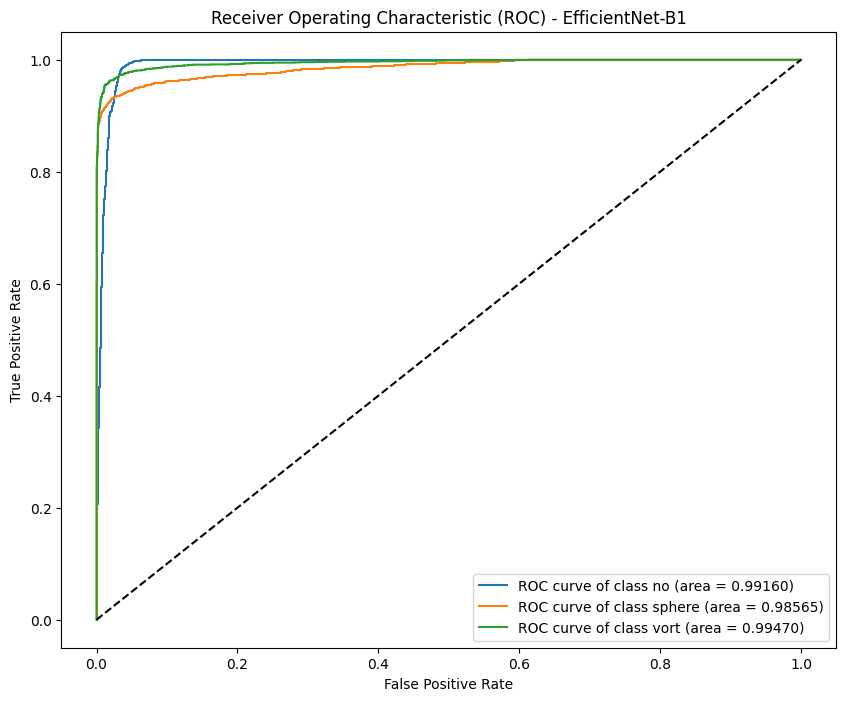

In [3]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from collections import OrderedDict
import seaborn as sns
import torchvision.transforms.functional as F



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
BATCH_SIZE = 32
IMAGE_SIZE = 240

DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/val' 
MODEL_PATH = '/kaggle/input/datasets/adman007/model-weights-for-inference/best_efficientNet_b1_classification_model.pt'


class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float().repeat(3, 1, 1)
        if self.transform: image = self.transform(image)
        return image, label


def load_model(path):
    model = models.efficientnet_b1(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    

    state_dict = torch.load(path, map_location=DEVICE)
   
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_state_dict[k.replace("_orig_mod.", "")] = v
        
    model.load_state_dict(new_state_dict)
    model = model.to(DEVICE)
    return model.eval()


test_transform = transforms.Compose([
    transforms.Resize(240),
    transforms.CenterCrop(240),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


test_dataset = GravitationalLensingDataset(DATA_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = load_model(MODEL_PATH)
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
fpr, tpr, roc_auc = dict(), dict(), dict()
target_names = list(test_dataset.class_to_idx.keys())

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {target_names[i]} (area = {roc_auc[i]:.5f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - EfficientNet-B1')
plt.legend(loc="lower right")
plt.savefig("EffNet-b1_roc_auc.png")
plt.show()

Running inference on cuda...


100%|██████████| 235/235 [00:08<00:00, 27.16it/s]


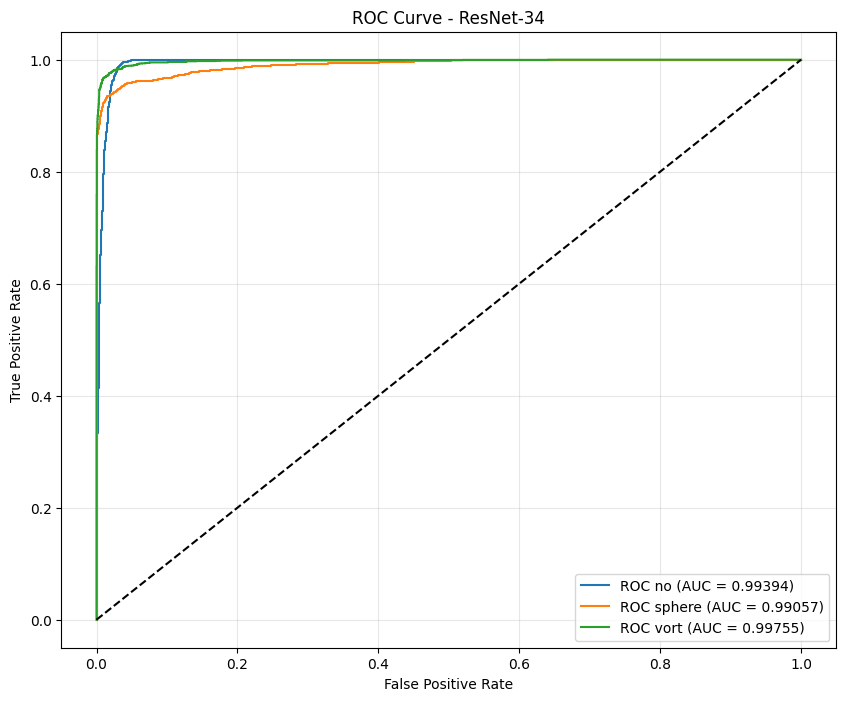

In [5]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
BATCH_SIZE = 32
DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/val' 
MODEL_PATH = '/kaggle/input/datasets/adman007/model-weights-for-inference/best_resnet34_classification_model.pt'


def load_model(path):
    model = models.resnet34(weights=None)
    
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    
    state_dict = torch.load(path, map_location=DEVICE)
    
    
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_state_dict[k.replace("_orig_mod.", "")] = v
        
    model.load_state_dict(new_state_dict)
    model = model.to(DEVICE)
    return model.eval()

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_dataset = GravitationalLensingDataset(DATA_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = load_model(MODEL_PATH)
all_probs = []
all_labels = []

print(f"Running inference on {DEVICE}...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# Compute ROC curve
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
fpr, tpr, roc_auc = dict(), dict(), dict()
target_names = list(test_dataset.class_to_idx.keys())

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC {target_names[i]} (AUC = {roc_auc[i]:.5f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet-34')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("resnet-34_roc_auc.png")
plt.show()

Running inference on cuda...


100%|██████████| 235/235 [00:08<00:00, 28.85it/s]


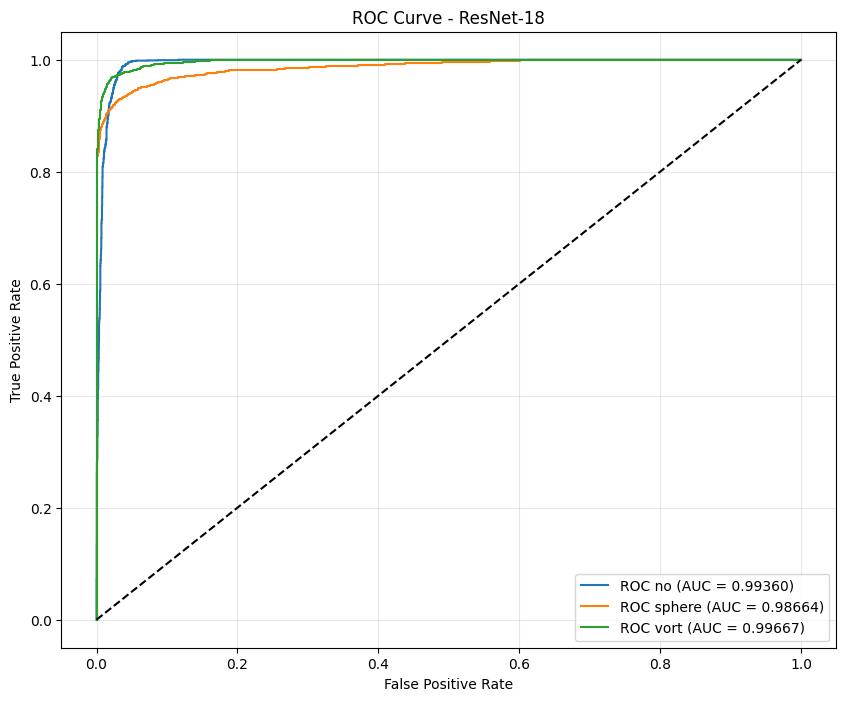

In [7]:
DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/val' 
MODEL_PATH = '/kaggle/input/datasets/adman007/model-weights-for-inference/best_resnet18_classification_model.pt'


def load_model(path):

    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    
    state_dict = torch.load(path, map_location=DEVICE)
    
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_state_dict[k.replace("_orig_mod.", "")] = v
        
    model.load_state_dict(new_state_dict)
    model = model.to(DEVICE)
    return model.eval()


test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


test_dataset = GravitationalLensingDataset(DATA_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = load_model(MODEL_PATH)
all_probs = []
all_labels = []

print(f"Running inference on {DEVICE}...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
fpr, tpr, roc_auc = dict(), dict(), dict()
target_names = list(test_dataset.class_to_idx.keys())

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC {target_names[i]} (AUC = {roc_auc[i]:.5f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet-18')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("resnet-18_roc_auc.png")
plt.show()

Running EfficientNet-B0 inference on cuda...


100%|██████████| 235/235 [00:08<00:00, 28.39it/s]


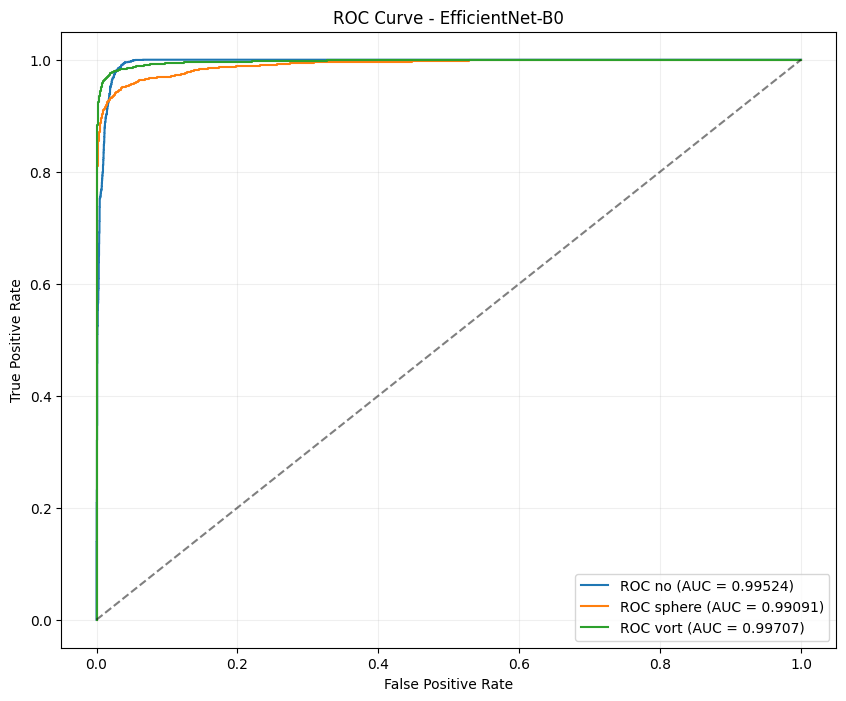

In [8]:
DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/val' 
MODEL_PATH = '/kaggle/input/datasets/adman007/model-weights-for-inference/best_efficientNet_b0_classification_model.pt'


def load_model(path):

    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)

    state_dict = torch.load(path, map_location=DEVICE)
    
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_state_dict[k.replace("_orig_mod.", "")] = v
        
    model.load_state_dict(new_state_dict)
    model = model.to(DEVICE)
    return model.eval()


test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


test_dataset = GravitationalLensingDataset(DATA_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = load_model(MODEL_PATH)
all_probs = []
all_labels = []

print(f"Running EfficientNet-B0 inference on {DEVICE}...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# Compute ROC curve
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
fpr, tpr, roc_auc = dict(), dict(), dict()
target_names = list(test_dataset.class_to_idx.keys())

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC {target_names[i]} (AUC = {roc_auc[i]:.5f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - EfficientNet-B0')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.savefig("effnet-b0_roc_auc.png")
plt.show()

Running Multi-Transform Ensemble Inference...


100%|██████████| 235/235 [00:11<00:00, 20.50it/s]


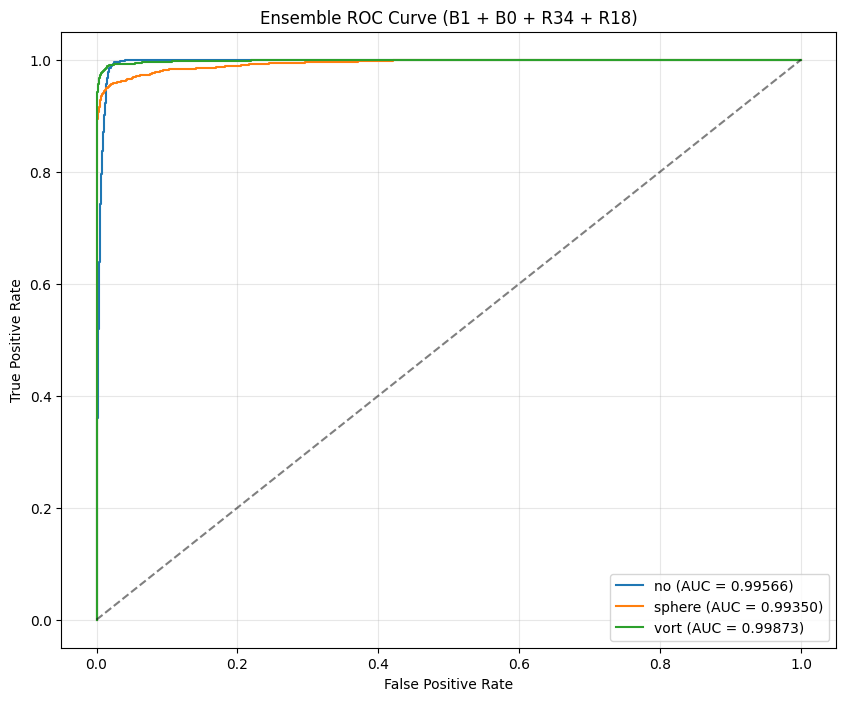

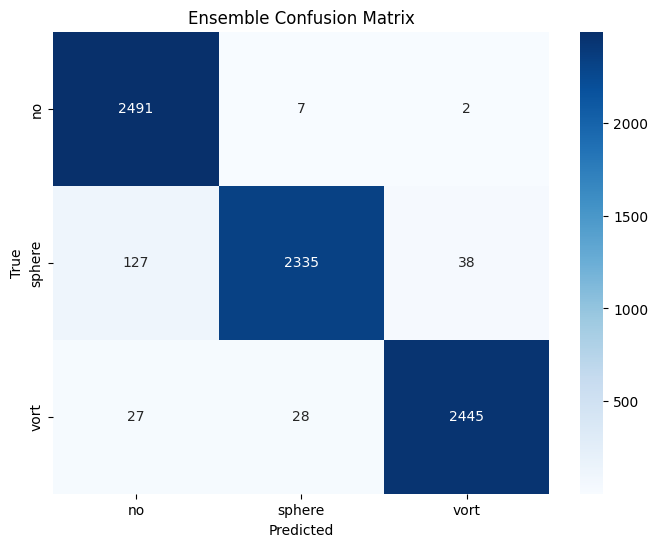

In [9]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from collections import OrderedDict


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
BATCH_SIZE = 32

DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/val'
WEIGHT_PATHS = {
    'efnet_b1': '/kaggle/input/datasets/adman007/model-weights-for-inference/best_efficientNet_b1_classification_model.pt',
    'efnet_b0': '/kaggle/input/datasets/adman007/model-weights-for-inference/best_efficientNet_b0_classification_model.pt',
    'resnet34': '/kaggle/input/datasets/adman007/model-weights-for-inference/best_resnet34_classification_model.pt',
    'resnet18': '/kaggle/input/datasets/adman007/model-weights-for-inference/best_resnet18_classification_model.pt'
}


transform_b1 = transforms.Compose([
    transforms.Resize(240),
    transforms.CenterCrop(240),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


transform_others = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float().repeat(3, 1, 1)
        return image, label


def clean_state_dict(path):
    state_dict = torch.load(path, map_location=DEVICE)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_state_dict[k.replace("_orig_mod.", "")] = v
    return new_state_dict


def get_ensemble():
    
    m1 = models.efficientnet_b1(weights=None)
    m1.classifier[1] = nn.Linear(m1.classifier[1].in_features, NUM_CLASSES)
    m1.load_state_dict(clean_state_dict(WEIGHT_PATHS['efnet_b1']))
    
    m2 = models.efficientnet_b0(weights=None)
    m2.classifier[1] = nn.Linear(m2.classifier[1].in_features, NUM_CLASSES)
    m2.load_state_dict(clean_state_dict(WEIGHT_PATHS['efnet_b0']))
    
    m3 = models.resnet34(weights=None)
    m3.fc = nn.Linear(m3.fc.in_features, NUM_CLASSES)
    m3.load_state_dict(clean_state_dict(WEIGHT_PATHS['resnet34']))
  
    m4 = models.resnet18(weights=None)
    m4.fc = nn.Linear(m4.fc.in_features, NUM_CLASSES)
    m4.load_state_dict(clean_state_dict(WEIGHT_PATHS['resnet18']))

    
    ensemble = {
        'b1': m1.to(DEVICE).eval(),
        'others': [m2.to(DEVICE).eval(), m3.to(DEVICE).eval(), m4.to(DEVICE).eval()]
    }
    return ensemble

test_dataset = GravitationalLensingDataset(DATA_DIR)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


models_dict = get_ensemble()
all_probs = []
all_labels = []

print("Running Multi-Transform Ensemble Inference...")
with torch.no_grad():
    for raw_inputs, labels in tqdm(test_loader):
        raw_inputs = raw_inputs.to(DEVICE)
        
        inputs_b1 = torch.stack([transform_b1(img) for img in raw_inputs])        
        inputs_others = torch.stack([transform_others(img) for img in raw_inputs])      
        batch_probs = []
               
        out_b1 = models_dict['b1'](inputs_b1)
        batch_probs.append(torch.softmax(out_b1, dim=1))
        
        
        for model in models_dict['others']:
            out = model(inputs_others)
            batch_probs.append(torch.softmax(out, dim=1))
        
        
        avg_probs = torch.stack(batch_probs).mean(dim=0)
        all_probs.append(avg_probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
all_preds = np.argmax(all_probs, axis=1)


y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
target_names = list(test_dataset.class_to_idx.keys())

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{target_names[i]} (AUC = {roc_auc:.5f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Ensemble ROC Curve (B1 + B0 + R34 + R18)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("ensemble_roc_auc.png")
plt.show()


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("ensemble_cm.png")
plt.show()